# 📚 Módulo 1.2: Librerías Fundamentales para Machine Learning
### Curso: **Machine Learning con Python** (IFCD093PO)
**Duración estimada:** 12 horas

---

## 🎯 Objetivos del Módulo

En este módulo, dominarás las tres librerías que forman la base de casi cualquier proyecto de Data Science y Machine Learning en Python. Al finalizar, serás capaz de:

- ✅ **NumPy**: Realizar cálculos numéricos eficientes con arrays multidimensionales.
- ✅ **Pandas**: Cargar, limpiar, manipular y analizar datos tabulares con DataFrames.
- ✅ **Matplotlib y Seaborn**: Crear visualizaciones de datos informativas y estéticamente agradables.

**Estas herramientas son el pan de cada día de un científico de datos. ¡Vamos a dominarlas!**

---

## 📚 Tabla de Contenidos

1. [**NumPy**: Computación Numérica](#1-numpy)
   - [¿Qué es NumPy y por qué es tan rápido?](#1.1-intro-numpy)
   - [Creación de Arrays](#1.2-creacion-arrays)
   - [Operaciones y Broadcasting](#1.3-operaciones)
   - [Indexación y Slicing](#1.4-indexacion)
   - [Estadísticas y Álgebra Lineal](#1.5-estadisticas)

2. [**Pandas**: Manipulación de Datos](#2-pandas)
   - [Series y DataFrames](#2.1-series-dataframes)
   - [Lectura y Escritura de Datos (CSV)](#2.2-lectura-datos)
   - [Selección y Filtrado (loc, iloc)](#2.3-seleccion)
   - [Agrupación (GroupBy)](#2.4-groupby)
   - [Manejo de Datos Faltantes](#2.5-nulos)

3. [**Visualización**: Matplotlib y Seaborn](#3-visualizacion)
   - [Anatomía de un Gráfico con Matplotlib](#3.1-matplotlib)
   - [Gráficos Estadísticos con Seaborn](#3.2-seaborn)

4. [Resumen y Próximos Pasos](#4-resumen)

---

## ⚙️ Preparación: Importar las librerías

Por convención, siempre importamos estas librerías con alias específicos. Esto hace el código más corto y legible.

In [2]:
# %pip install numpy pandas matplotlib seaborn
# Importar las librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuraciones recomendadas para una mejor visualización
sns.set_style("whitegrid") # Estilo de los gráficos de Seaborn
plt.rcParams["figure.figsize"] = (10, 6) # Tamaño por defecto de los gráficos

---

## 🔢 1. NumPy: Computación Numérica <a id='1-numpy'></a>

### 1.1 ¿Qué es NumPy y por qué es tan rápido? <a id='1.1-intro-numpy'></a>

**NumPy** (Numerical Python) es la librería fundamental para la computación científica en Python. Su objeto principal es el **array multidimensional** (`ndarray`).

**¿Por qué es más rápido que las listas de Python?**
- **Memoria Contigua**: Los elementos de un array de NumPy se guardan uno al lado del otro en la memoria, permitiendo un acceso mucho más rápido.
- **Código Optimizado**: Muchas de sus operaciones están escritas en C o Fortran, lenguajes de bajo nivel mucho más rápidos que Python.
- **Vectorización**: Permite aplicar una operación a todo un array a la vez, sin necesidad de bucles `for` explícitos en Python.

In [3]:
# Comparación de velocidad: NumPy vs Listas
lista_py = list(range(1_000_000)) # Lista de Python con 1 millón de números
array_np = np.arange(1_000_000) # Array de NumPy con 1 millón de números

print("Calculando el cuadrado de 1 millón de números:")

# Con listas de Python (usando un bucle)
print("\nCon listas de Python:")
%timeit [x**2 for x in lista_py] # Usando comprensión de listas

# Con NumPy (vectorizado)
print("\nCon NumPy:")
%timeit array_np**2 # Operación vectorizada

Calculando el cuadrado de 1 millón de números:

Con listas de Python:
70.9 ms ± 1.86 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

Con NumPy:
2.71 ms ± 82.5 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


### 1.2 Creación de Arrays <a id='1.2-creacion-arrays'></a>

Hay muchas formas de crear arrays en NumPy.

In [ ]:
# Desde una lista de Python
array_1d = np.array([1, 2, 3, 4, 5])
print("Array 1D:", array_1d)

array_2d = np.array([[1, 2, 3], [4, 5, 6]])
print("\nArray 2D (matriz):\n", array_2d)

# Con funciones de NumPy
array_zeros = np.zeros((2, 3)) # Array de ceros
print("\nArray de ceros:\n", array_zeros)

array_ones = np.ones((3, 3)) # Array de unos
print("\nArray de unos:\n", array_ones)

array_range = np.arange(0, 10, 2) # Similar a range() de Python. El tercer parámetro es el paso
print("\nArray con arange(0, 10, 2):", array_range)

array_linspace = np.linspace(0, 1, 5) # 5 números espaciados igualmente entre 0 y 1
print("\nArray con linspace(0, 1, 5):", array_linspace)

array_random = np.random.rand(2, 3) # Números aleatorios entre 0 y 1
print("\nArray aleatorio:\n", array_random) 

Array 1D: [1 2 3 4 5]

Array 2D (matriz):
 [[1 2 3]
 [4 5 6]]

Array de ceros:
 [[0. 0. 0.]
 [0. 0. 0.]]

Array de unos:
 [[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]

Array con arange(0, 10, 2): [0 2 4 6 8]

Array con linspace(0, 1, 5): [0.  0.2 0.4 0.6 0.8 1. ]

Array aleatorio:
 [[0.7382891  0.87488842 0.85161544]
 [0.37632903 0.02291462 0.21224129]]


### 1.3 Operaciones y Broadcasting <a id='1.3-operaciones'></a>

Las operaciones se aplican elemento a elemento. **Broadcasting** es la habilidad de NumPy de tratar con arrays de diferentes formas durante las operaciones aritméticas.

In [11]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

# Operaciones elemento a elemento
print("Suma:", a + b)
print("Multiplicación:", a * b)

# Broadcasting: operando un array con un escalar
print("\nBroadcasting:")
print("Array + 10:", a + 10)
print("Array * 2:", a * 2)

# Ejemplo más complejo de broadcasting
matriz = np.array([[1, 2, 3], [4, 5, 6]])
vector = np.array([10, 20, 30])
print("\nMatriz + Vector:")
print(matriz + vector) # El vector se "estira" para sumarse a cada fila

Suma: [5 7 9]
Multiplicación: [ 4 10 18]

Broadcasting:
Array + 10: [11 12 13]
Array * 2: [2 4 6]

Matriz + Vector:
[[11 22 33]
 [14 25 36]]


### 1.4 Indexación y Slicing <a id='1.4-indexacion'></a>

Funciona de forma similar a las listas, pero con más dimensiones.

In [ ]:
data = np.arange(1, 13).reshape(3, 4) # Crea un array de 1 a 12 y lo remodela a 3x4
print("Matriz de datos:\n", data)

# Acceder a un elemento: data[fila, columna]
print("\nElemento en la fila 1, columna 2:", data[1, 2]) # Es 7
print("Elemento en la fila 0, columna 3:", data[0, 3]) # Es 4

# Slicing
print("\nPrimera fila completa:", data[0, :])
print("Segunda columna completa:", data[:, 1])
print("\nSubmatriz (primeras 2 filas, columnas 1 y 2):\n", data[0:2, 1:3])

# Indexación booleana (muy potente)
mayores_que_5 = data > 5
print("\nMáscara booleana (elementos > 5):\n", mayores_que_5)
print("\nElementos mayores que 5:", data[mayores_que_5])

Matriz de datos:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

Elemento en la fila 1, columna 2: 7

Primera fila completa: [1 2 3 4]
Segunda columna completa: [ 2  6 10]

Submatriz (primeras 2 filas, columnas 1 y 2):
 [[2 3]
 [6 7]]

Máscara booleana (elementos > 5):
 [[False False False False]
 [False  True  True  True]
 [ True  True  True  True]]

Elementos mayores que 5: [ 6  7  8  9 10 11 12]


### ✅ Ejercicio 1 (NumPy): Normalización de Datos

La normalización Z-score es una técnica muy común en ML. La fórmula es: `(x - media) / desv_estandar`.

1. Crea un array de NumPy con 10 números aleatorios (ej: `np.random.randint(50, 100, 10)`).
2. Calcula la media (`.mean()`) y la desviación estándar (`.std()`) del array.
3. Aplica la fórmula de Z-score para normalizar los datos.
4. Imprime el array original y el normalizado.

In [14]:
# Tu código aquí
array_sin = np.random.randint(50,100,10) # Array de 10 números aleatorios entre 50 y 100
des_est = array_sin.std() # Desviación estándar
media = array_sin.mean() # Media
z_score = (array_sin - media) / des_est # Normalización Z-score
print(f"Array original {array_sin}")
print(f"Array normalizado {z_score}")

Array original [63 57 54 73 52 81 66 90 58 64]
Array normalizado [-0.24120013 -0.75805754 -1.01648624  0.6202289  -1.18877205  1.30937211
  0.01722858  2.08465823 -0.67191464 -0.15505722]


<details>
<summary>💡 <b>Solución</b></summary>

```python
np.random.seed(42) # Para que los resultados sean reproducibles
datos_originales = np.random.randint(50, 100, 10)

media = datos_originales.mean()
desv_estandar = datos_originales.std()

datos_normalizados = (datos_originales - media) / desv_estandar

print(f"Datos originales: {datos_originales}")
print(f"Media: {media:.2f}, Desv. Estándar: {desv_estandar:.2f}")
print(f"\nDatos normalizados (Z-score):\n{datos_normalizados}")

# Comprobación: la media de los datos normalizados debe ser cercana a 0 y la desv. estándar a 1
print(f"\nMedia de datos normalizados: {datos_normalizados.mean():.2f}")
print(f"Desv. Estándar de datos normalizados: {datos_normalizados.std():.2f}")
```
</details>

---

## 🐼 2. Pandas: Manipulación de Datos <a id='2-pandas'></a>

**Pandas** es la librería esencial para trabajar con datos "estructurados" (tablas, como en Excel o SQL). Se construye sobre NumPy.

### 2.1 Series y DataFrames <a id='2.1-series-dataframes'></a>

- **Serie**: Un array unidimensional etiquetado (como una columna de una tabla). Puede contener cualquier tipo de dato.
- **DataFrame**: Una tabla bidimensional etiquetada (como una hoja de cálculo). Es la estructura de datos principal de Pandas.

In [ ]:
# Importamos librería
import pandas as pd
# Creación de una Serie, usaremos pd.Series(), esta clase es similar a un array unidimensional pero con etiquetas
serie_poblacion = pd.Series([8_000_000, 3_200_000, 1_600_000], # Aquí van los datos
                              index=["Nueva York", "Madrid", "Barcelona"]) # Aquí definimos índices personalizados
print("Serie de población:\n", serie_poblacion)

# Creación de un DataFrame desde un diccionario
datos = {
    'País': ['España', 'Francia', 'Alemania', 'Italia'],
    'Capital': ['Madrid', 'París', 'Berlín', 'Roma'],
    'Población (millones)': [47, 65, 83, 60]
}
df = pd.DataFrame(datos)

print("\nDataFrame de países:")
print(df) # Queda menos legible en notebooks usar display() en lugar de print() 
display(df) # display() es mejor que print() para DataFrames en notebooks

Serie de población:
 Nueva York    8000000
Madrid        3200000
Barcelona     1600000
dtype: int64

DataFrame de países:
       País Capital  Población (millones)
0    España  Madrid                    47
1   Francia   París                    65
2  Alemania  Berlín                    83
3    Italia    Roma                    60


,País,Capital,Población (millones)
0,España,Madrid,47
1,Francia,París,65
2,Alemania,Berlín,83
3,Italia,Roma,60


### 2.2 Lectura y Escritura de Datos (CSV) <a id='2.2-lectura-datos'></a>

Una de las tareas más comunes es cargar datos desde un archivo. Pandas lo hace muy fácil, especialmente con archivos CSV (Comma-Separated Values).

In [9]:
# Vamos a crear un archivo CSV de ejemplo para poder leerlo

# Primero, creamos el archivo CSV de ejemplo
contenido_csv = """ID,Nombre,Edad,Salario
1,Ana,28,50000
2,Luis,34,62000
3,Marta,45,75000
4,Javier,22,
5,Sofia,39,68000
"""
# Guardamos el contenido en un archivo llamado "empleados.csv"
with open("empleados.csv", "w") as f:
    f.write(contenido_csv)

# Leer el archivo CSV en un DataFrame
df_empleados = pd.read_csv("empleados.csv")

print("DataFrame cargado desde 'empleados.csv':")
display(df_empleados)

# Métodos básicos para explorar un DataFrame
print("\nPrimeras 3 filas (.head(3)):") # Muestra las primeras 3 filas
display(df_empleados.head(3))
display(df_empleados.tail(2)) # Muestra las últimas 2 filas

print("\nInformación del DataFrame (.info()):") # Tipos de datos y valores nulos
df_empleados.info()

print("\nEstadísticas descriptivas (.describe()):") # Estadísticas para columnas numéricas
display(df_empleados.describe())

DataFrame cargado desde 'empleados.csv':


,ID,Nombre,Edad,Salario
0,1,Ana,28,50000.0
1,2,Luis,34,62000.0
2,3,Marta,45,75000.0
3,4,Javier,22,NaN
4,5,Sofia,39,68000.0



Primeras 3 filas (.head(3)):


,ID,Nombre,Edad,Salario
0,1,Ana,28,50000.0
1,2,Luis,34,62000.0
2,3,Marta,45,75000.0


,ID,Nombre,Edad,Salario
3,4,Javier,22,NaN
4,5,Sofia,39,68000.0



Información del DataFrame (.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ID       5 non-null      int64  
 1   Nombre   5 non-null      object 
 2   Edad     5 non-null      int64  
 3   Salario  4 non-null      float64
dtypes: float64(1), int64(2), object(1)
memory usage: 292.0+ bytes

Estadísticas descriptivas (.describe()):


,ID,Edad,Salario
count,5.000000,5.000000,4.00000
mean,3.000000,33.600000,63750.00000
std,1.581139,9.016651,10594.81005
min,1.000000,22.000000,50000.00000
25%,2.000000,28.000000,59000.00000
50%,3.000000,34.000000,65000.00000
75%,4.000000,39.000000,69750.00000
max,5.000000,45.000000,75000.00000


### 2.3 Selección y Filtrado (loc, iloc) <a id='2.3-seleccion'></a>

Hay dos formas principales de seleccionar datos:
- **`.loc`**: Selecciona por **etiquetas** (nombres de filas/columnas).
- **`.iloc`**: Selecciona por **posición** entera (índices numéricos).

In [15]:
# Seleccionar una columna 
nombres = df_empleados['Nombre']
print("Columna 'Nombre':\n", nombres)

# Seleccionar múltiples columnas
nombre_y_salario = df_empleados[['Nombre', 'Salario']]
print("\nColumnas 'Nombre' y 'Salario':")
display(nombre_y_salario)

# .iloc: seleccionar la primera fila (posición 0)
primera_fila = df_empleados.iloc[0]
print("\nPrimera fila (iloc[0]):\n", primera_fila)

# .loc: seleccionar la fila con índice 2
fila_indice_2 = df_empleados.loc[2]
print("\nFila con índice 2 (loc[2]):\n", fila_indice_2)

# Filtrado booleano: empleados que ganan más de 60000
salarios_altos = df_empleados[df_empleados['Salario'] > 60000]
print("\nEmpleados con salario > 60000:")
display(salarios_altos)

Columna 'Nombre':
 0       Ana
1      Luis
2     Marta
3    Javier
4     Sofia
Name: Nombre, dtype: object

Columnas 'Nombre' y 'Salario':


,Nombre,Salario
0,Ana,50000.0
1,Luis,62000.0
2,Marta,75000.0
3,Javier,NaN
4,Sofia,68000.0



Primera fila (iloc[0]):
 ID               1
Nombre         Ana
Edad            28
Salario    50000.0
Name: 0, dtype: object

Fila con índice 2 (loc[2]):
 ID               3
Nombre       Marta
Edad            45
Salario    75000.0
Name: 2, dtype: object

Empleados con salario > 60000:


,ID,Nombre,Edad,Salario
1,2,Luis,34,62000.0
2,3,Marta,45,75000.0
4,5,Sofia,39,68000.0


### 2.4 Agrupación (GroupBy) <a id='2.4-groupby'></a>

El `groupby` es una operación extremadamente potente que implica:
1. **Dividir** los datos en grupos basados en algún criterio.
2. **Aplicar** una función a cada grupo de forma independiente.
3. **Combinar** los resultados en una estructura de datos.

In [16]:
# Creemos un DataFrame más complejo
data_ventas = {
    'Departamento': ['Deportes', 'Hogar', 'Deportes', 'Tecnología', 'Hogar', 'Tecnología'],
    'Vendedor': ['Ana', 'Luis', 'Ana', 'Marta', 'Luis', 'Marta'],
    'Ventas': [200, 150, 250, 300, 180, 320]
} # Esta estructura es un diccionario
df_ventas = pd.DataFrame(data_ventas) # Ahora creamos el DataFrame partiendonos del diccionario
print("DataFrame de ventas:")
display(df_ventas)

# Agrupar por 'Departamento' y calcular la suma de ventas
ventas_por_depto = df_ventas.groupby('Departamento')['Ventas'].sum()
print("\nSuma de ventas por departamento:")
print(ventas_por_depto)

# Agrupar por 'Vendedor' y calcular la media y el total de ventas
stats_vendedor = df_ventas.groupby('Vendedor')['Ventas'].agg(['mean', 'sum']) # .agg es para agregar múltiples estadísticas
# si sólo usamos .mean() o .sum() la sintaxis sería de la siguiente forma:
# stats_vendedor_mean = df_ventas.groupby('Vendedor')['Ventas'].mean()
# stats_vendedor_sum = df_ventas.groupby('Vendedor')['Ventas'].sum()
print("\nEstadísticas por vendedor:")
display(stats_vendedor)

DataFrame de ventas:


,Departamento,Vendedor,Ventas
0,Deportes,Ana,200
1,Hogar,Luis,150
2,Deportes,Ana,250
3,Tecnología,Marta,300
4,Hogar,Luis,180
5,Tecnología,Marta,320



Suma de ventas por departamento:
Departamento
Deportes      450
Hogar         330
Tecnología    620
Name: Ventas, dtype: int64

Estadísticas por vendedor:


,mean,sum
Vendedor,,
Ana,225.0,450
Luis,165.0,330
Marta,310.0,620


### ✅ Ejercicio 2 (Pandas): Análisis de Datos de Películas

1. Crea un DataFrame con datos de películas: `Titulo`, `Director`, `Año`, `Puntuacion` (de 1 a 10).
2. Filtra y muestra solo las películas con una puntuación mayor o igual a 8.
3. Agrupa por `Director` y calcula la puntuación media de sus películas.

In [20]:
# Tu código aquí
datos_peliculas = {
    'Titulo': ['Pulp Fiction', 'The Dark Knight', 'Forrest Gump', 'The Dark Knight Rises', 'Inception'],
    'Director': ['Tarantino', 'Nolan', 'Zemeckis', 'Nolan', 'Nolan'],
    'Año': [1994, 2008, 1994, 2012, 2010],
    'Puntuacion': [8.9, 9.0, 6.8, 8.4, 7.8]
}
df_peliculas = pd.DataFrame(datos_peliculas)
display(df_peliculas)
# 1. Filtra las mejores películas
df_buenas = df_peliculas[df_peliculas["Puntuacion"] > 8]
display(df_buenas)
# 2. Agrupa por director
directores = df_peliculas.groupby("Director")["Titulo"].count()
display(directores)

,Titulo,Director,Año,Puntuacion
0,Pulp Fiction,Tarantino,1994,8.9
1,The Dark Knight,Nolan,2008,9.0
2,Forrest Gump,Zemeckis,1994,6.8
3,The Dark Knight Rises,Nolan,2012,8.4
4,Inception,Nolan,2010,7.8


,Titulo,Director,Año,Puntuacion
0,Pulp Fiction,Tarantino,1994,8.9
1,The Dark Knight,Nolan,2008,9.0
3,The Dark Knight Rises,Nolan,2012,8.4


Director
Nolan        3
Tarantino    1
Zemeckis     1
Name: Titulo, dtype: int64

<details>
<summary>💡 <b>Solución</b></summary>

```python
mejores_peliculas = df_peliculas[df_peliculas['Puntuacion'] >= 8.8]
print("Películas con puntuación >= 8.8:")
display(mejores_peliculas)

puntuacion_media_director = df_peliculas.groupby('Director')['Puntuacion'].mean().sort_values(ascending=False)
print("\nPuntuación media por director:")
print(puntuacion_media_director)
```
</details>

---

## 📊 3. Visualización: Matplotlib y Seaborn <a id='3-visualizacion'></a>

Una imagen vale más que mil palabras (o mil filas de datos). La visualización es clave para entender patrones, tendencias y outliers (valores atípicos).
º
- **Matplotlib**: Es la librería base. Potente y altamente personalizable, pero a veces verbosa.
- **Seaborn**: Construida sobre Matplotlib. Ofrece una interfaz de más alto nivel para crear gráficos estadísticos atractivos con menos código.

### 3.1 Anatomía de un Gráfico con Matplotlib <a id='3.1-matplotlib'></a>

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

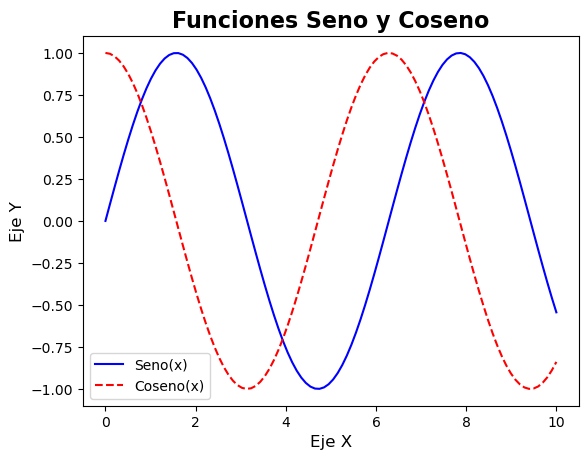

In [23]:
# Datos de ejemplo
x = np.linspace(0, 10, 100) # 100 puntos entre 0 y 10
y_seno = np.sin(x) # Datos del seno para el eje Y. Con esto conseguimos una onda suave
y_coseno = np.cos(x) # Datos del coseno para el eje Y. Con esto conseguimos una onda suave

# Crear el gráfico
plt.plot(x, y_seno, label='Seno(x)', color='blue', linestyle='-') # Línea sólida azul para Seno
plt.plot(x, y_coseno, label='Coseno(x)', color='red', linestyle='--') # Línea discontinua roja para Coseno

# Añadir títulos y etiquetas
plt.title('Funciones Seno y Coseno', fontsize=16, fontweight='bold') # Título con formato
plt.xlabel('Eje X', fontsize=12) # Etiqueta del eje X
plt.ylabel('Eje Y', fontsize=12) # Etiqueta del eje Y

# Añadir leyenda
plt.legend()

# Mostrar el gráfico
plt.show()

### 3.2 Gráficos Estadísticos con Seaborn <a id='3.2-seaborn'></a>

Seaborn simplifica la creación de gráficos comunes en el análisis de datos.

Recordatorio del DataFrame de empleados:


,ID,Nombre,Edad,Salario
0,1,Ana,28,50000.0
1,2,Luis,34,62000.0
2,3,Marta,45,75000.0
3,4,Javier,22,NaN
4,5,Sofia,39,68000.0


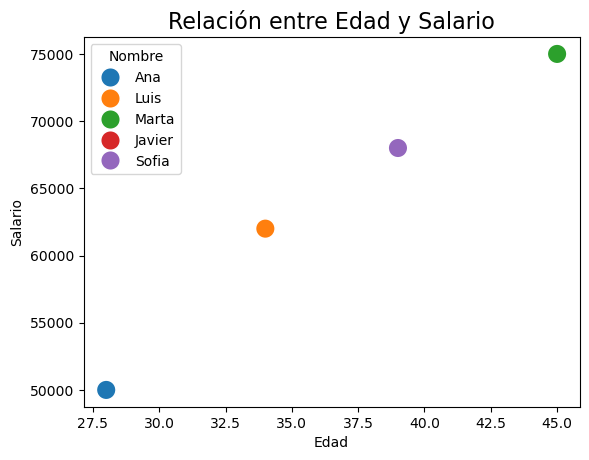

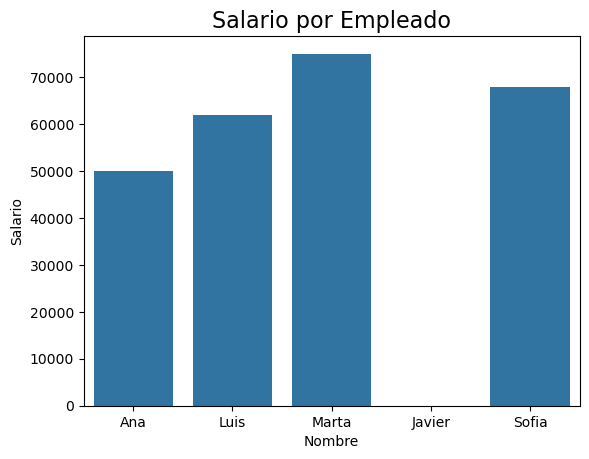

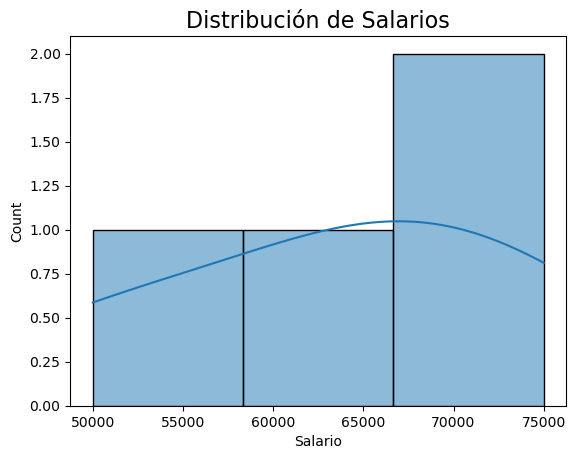

In [24]:
# Con seaborn conseguimos gráficos más atractivos lo que facilita su interpretación

# Usaremos el DataFrame de empleados que creamos antes
print("Recordatorio del DataFrame de empleados:")
display(df_empleados)

# Gráfico de dispersión (scatterplot) para ver la relación entre edad y salario
plt.figure() # Creamos una nueva figura
# Definimos el gráfico de dispersión
# Los parámetros son:
# data: el DataFrame que contiene los datos
# x: la columna para el eje X
# y: la columna para el eje Y
# hue: la columna para diferenciar colores (aquí usamos el nombre del empleado)
# s: tamaño de los puntos
sns.scatterplot(data=df_empleados, x='Edad', y='Salario', hue='Nombre', s=200)
plt.title('Relación entre Edad y Salario', fontsize=16)
plt.show()

# Gráfico de barras (barplot) para comparar salarios
plt.figure() # Creamos una nueva figura
# Definimos el gráfico de barras
# Los parámetros son similares a scatterplot pero aquí comparamos categorías
sns.barplot(data=df_empleados, x='Nombre', y='Salario')
plt.title('Salario por Empleado', fontsize=16)
plt.show()

# Histograma para ver la distribución de una variable
plt.figure()
sns.histplot(data=df_empleados, x='Salario', kde=True) # kde=True añade una curva de densidad para mejor visualización 
plt.title('Distribución de Salarios', fontsize=16)
plt.show()

### ✅ Ejercicio 3 (Visualización): Gráfico de Películas

Usando el DataFrame de películas del ejercicio anterior:

1. Crea un **gráfico de barras** que muestre la puntuación de cada película.
2. Crea un **gráfico de conteo** (`countplot`) que muestre cuántas películas ha dirigido cada director en el dataset.

In [ ]:
# Tu código aquí
# 1. Gráfico de barras de puntuaciones
plt.figure()
sns.barplot(data=df_peliculas, x='Titulo', y='Puntuacion')
plt.title('Puntuación de Peliculas', fontsize=16)
plt.show()
# 2. Gráfico de conteo de directores
plt.figure()
sns.countplot(data=df_peliculas, x="Director")
plt.title('Peliculas por Directo', fontsize=16)
plt.show()

<details>
<summary>💡 <b>Solución</b></summary>

```python
# 1. Gráfico de barras de puntuaciones
plt.figure(figsize=(12, 6))
sns.barplot(data=df_peliculas, x='Titulo', y='Puntuacion', hue='Director')
plt.title('Puntuación por Película', fontsize=16)
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para que no se solapen
plt.ylim(8, 9.2) # Ajustar el límite del eje Y para ver mejor las diferencias
plt.show()

# 2. Gráfico de conteo de directores
plt.figure(figsize=(10, 6))
sns.countplot(data=df_peliculas, x='Director', order=df_peliculas['Director'].value_counts().index)
plt.title('Número de Películas por Director en el Dataset', fontsize=16)
plt.show()
```
</details>

---

## 📝 4. Resumen y Próximos Pasos <a id='4-resumen'></a>

### 🎉 ¡Felicidades! Has dominado las librerías fundamentales

#### ✅ Lo que has aprendido:

1. **NumPy**
   - Crear y manipular arrays multidimensionales.
   - Realizar operaciones matemáticas vectorizadas y usar broadcasting.
   - Seleccionar datos con slicing e indexación booleana.

2. **Pandas**
   - Trabajar con Series y DataFrames.
   - Cargar datos desde archivos CSV y explorarlos.
   - Filtrar y seleccionar datos de manera precisa con `.loc`, `.iloc` y condiciones booleanas.
   - Agrupar datos y calcular estadísticas con `groupby`.

3. **Matplotlib y Seaborn**
   - Entender la estructura básica de un gráfico.
   - Crear gráficos de líneas, barras, dispersión e histogramas.
   - Usar Seaborn para crear visualizaciones estadísticas atractivas con poco código.

---

### 🚀 Próximo Módulo: Introducción al Machine Learning

Ahora que sabes cómo manejar y visualizar datos, estás listo para el siguiente gran paso: **¡entrenar tu primer modelo de Machine Learning!**

En el próximo módulo aprenderás:
- ¿Qué es realmente el Machine Learning?
- Los diferentes tipos de aprendizaje (supervisado, no supervisado).
- El flujo de trabajo completo de un proyecto de ML, desde la carga de datos hasta la evaluación del modelo.
- Conceptos clave como *overfitting*, *underfitting* y *validación cruzada*.

**¡Aquí es donde todo lo que has aprendido se une para crear algo increíble!**